#### PHASE 6 — Business Decision Simulation

This phase converts your ML model into a real bank decision system.

Banks do NOT just use predictions.
They use probability thresholds to decide:

Approve loan

Reject loan

Send for manual review

🎯 Goal of Phase 6

We will simulate:

1️⃣ Risk thresholds
2️⃣ Approval rate
3️⃣ Default rate
4️⃣ Bank portfolio risk

This is exactly how credit scoring works in real banks.

In [1]:
# STEP 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

In [2]:
# STEP 2 — Load Model Outputs
# We need predicted probabilities from XGBoost model.

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

import joblib
xgb_model = joblib.load("../models/xgboost_model.pkl")

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [3]:
# ✅ STEP 3 — Create Simulation DataFrame

simulation_df = pd.DataFrame({
    "actual_default": y_test,
    "predicted_default_prob": y_prob
})

simulation_df.head()

,actual_default,predicted_default_prob
0,0,0.334700
1,0,0.337396
2,0,0.820003
3,0,0.516396
4,0,0.502339


In [4]:
# ✅ STEP 4 — Define Risk Threshold

# Example threshold:
# Approve if probability < 0.5
# Reject if probability ≥ 0.5

threshold = 0.5

simulation_df["approved"] = simulation_df["predicted_default_prob"] < threshold

In [5]:
# ✅ STEP 5 — Approval Rate

approval_rate = simulation_df["approved"].mean()

print("Approval Rate:", approval_rate)

Approval Rate: 0.6963725346731053


In [6]:
# ✅ STEP 6 — Default Rate Among Approved

approved_customers = simulation_df[simulation_df["approved"] == True]

default_rate = approved_customers["actual_default"].mean()

print("Default Rate Among Approved:", default_rate)

Default Rate Among Approved: 0.04088351350720306


In [8]:
# ✅ STEP 7 — Simulate Multiple Thresholds  -   This is where business insight comes.

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:

    simulation_df["approved"] = simulation_df["predicted_default_prob"] < t
    
    approval_rate = simulation_df["approved"].mean()
    
    approved = simulation_df[simulation_df["approved"] == True]
    
    default_rate = approved["actual_default"].mean()
    
    results.append((t, approval_rate, default_rate))

results_df = pd.DataFrame(results, columns=["threshold","approval_rate","default_rate"])

results_df


,threshold,approval_rate,default_rate
0,0.10,0.041819,0.013219
1,0.15,0.105702,0.014767
2,0.20,0.193600,0.017637
3,0.25,0.286620,0.020138
4,0.30,0.382892,0.024290
5,0.35,0.471229,0.027189
6,0.40,0.552867,0.031350
7,0.45,0.628701,0.036077
8,0.50,0.696373,0.040884
9,0.55,0.758776,0.045278


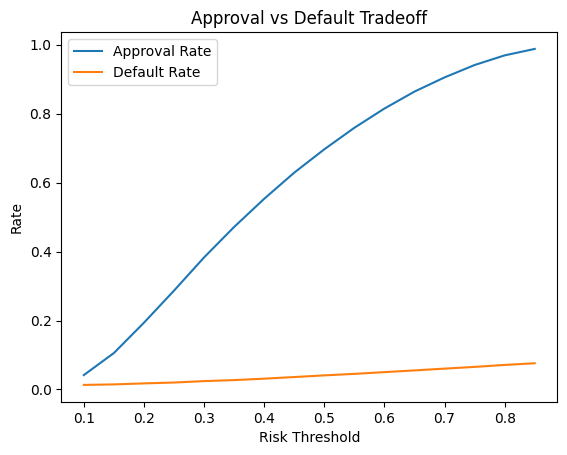

In [9]:
# ✅ STEP 8 — Plot Business Tradeoff

plt.plot(results_df["threshold"], results_df["approval_rate"], label="Approval Rate")
plt.plot(results_df["threshold"], results_df["default_rate"], label="Default Rate")

plt.xlabel("Risk Threshold")
plt.ylabel("Rate")
plt.title("Approval vs Default Tradeoff")

plt.legend()
plt.show()